In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.nn as nn

In [3]:
df = pd.read_csv("seismic_activity_svm.csv")
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
None
       underground_wave_energy  vibration_axis_variation  \
count               400.000000              4.000000e+02   
mean                  0.000000              8.881784e-18   
std                   7.719350              1.751650e+00   
min                  -9.999954             -3.000000e+00   
25%                  -6.134779             -1.500000e+00   
50%                   0.000000              0.000000e+00   
75%                   6.134779              1.500000e+00   
max                   9.999954              3.000000e+00   

       seismic_event_dete

In [5]:
x = torch.tensor(df[['underground_wave_energy','vibration_axis_variation']].values,dtype=torch.float32)
y = torch.tensor(df['seismic_event_detected'].values,dtype=torch.float32).unsqueeze(1)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42)

<function matplotlib.pyplot.show(close=None, block=None)>

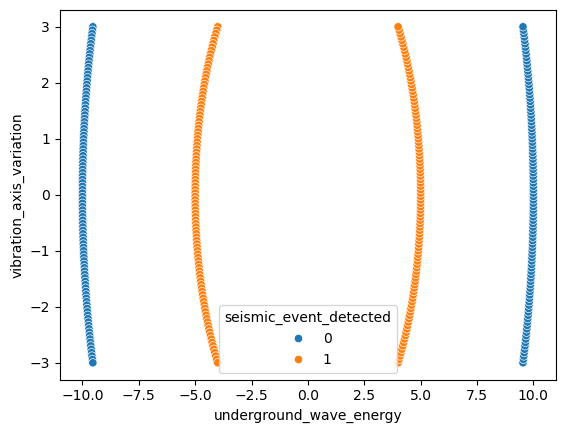

In [7]:
sns.scatterplot(x=df['underground_wave_energy'], y=df['vibration_axis_variation'], hue=df['seismic_event_detected'])
plt.show

In [14]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5,dtype=torch.float32)
        self.relu_1 = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=5,out_features=7,dtype=torch.float32)
        self.relu_2 = nn.ReLU()
        self.layer_3 = nn.Linear(in_features=7,out_features=1,dtype=torch.float32)
        
    def forward(self,x):
        out = self.layer_1(x)
        out = self.relu_1(out)
        out = self.layer_2(out)
        out = self.relu_2(out)
        out = self.layer_3(out)
        return out

In [15]:
model = SimpleModel()

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [17]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy = (correct / len(y_pred)) *100
    return accuracy

In [18]:
torch.manual_seed(42)
epochs = 200

epoch_count = []
train_loss_count = []
train_acc_count = []

for epoch in range(epochs):
    model.train()
    y_logits = model(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_train,y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc  = calculate_accuracy(y_test,test_pred) 

        epoch_count.append(epoch)
        train_loss_count.append(loss.item())
        train_acc_count.append(acc)
        
        if epoch % 10 == 0:
            print(f"Epoch:{epoch}, Loss:{loss}, Acc:{acc}, Test_Loss:{test_loss}, Test_Acc:{test_acc}")

Epoch:0, Loss:0.7049009203910828, Acc:46.875, Test_Loss:0.687865138053894, Test_Acc:46.25
Epoch:10, Loss:0.6347492337226868, Acc:48.75, Test_Loss:0.5852799415588379, Test_Acc:55.00000000000001
Epoch:20, Loss:0.599165678024292, Acc:49.6875, Test_Loss:0.5594746470451355, Test_Acc:56.25
Epoch:30, Loss:0.5582748651504517, Acc:51.5625, Test_Loss:0.520613431930542, Test_Acc:55.00000000000001
Epoch:40, Loss:0.5060834884643555, Acc:70.0, Test_Loss:0.4751817286014557, Test_Acc:81.25
Epoch:50, Loss:0.43638938665390015, Acc:100.0, Test_Loss:0.40968719124794006, Test_Acc:100.0
Epoch:60, Loss:0.3463325500488281, Acc:100.0, Test_Loss:0.32307499647140503, Test_Acc:100.0
Epoch:70, Loss:0.24280786514282227, Acc:100.0, Test_Loss:0.22767560184001923, Test_Acc:100.0
Epoch:80, Loss:0.14899542927742004, Acc:100.0, Test_Loss:0.13847780227661133, Test_Acc:100.0
Epoch:90, Loss:0.08660975843667984, Acc:100.0, Test_Loss:0.08235146105289459, Test_Acc:100.0
Epoch:100, Loss:0.051695846021175385, Acc:100.0, Test_Los

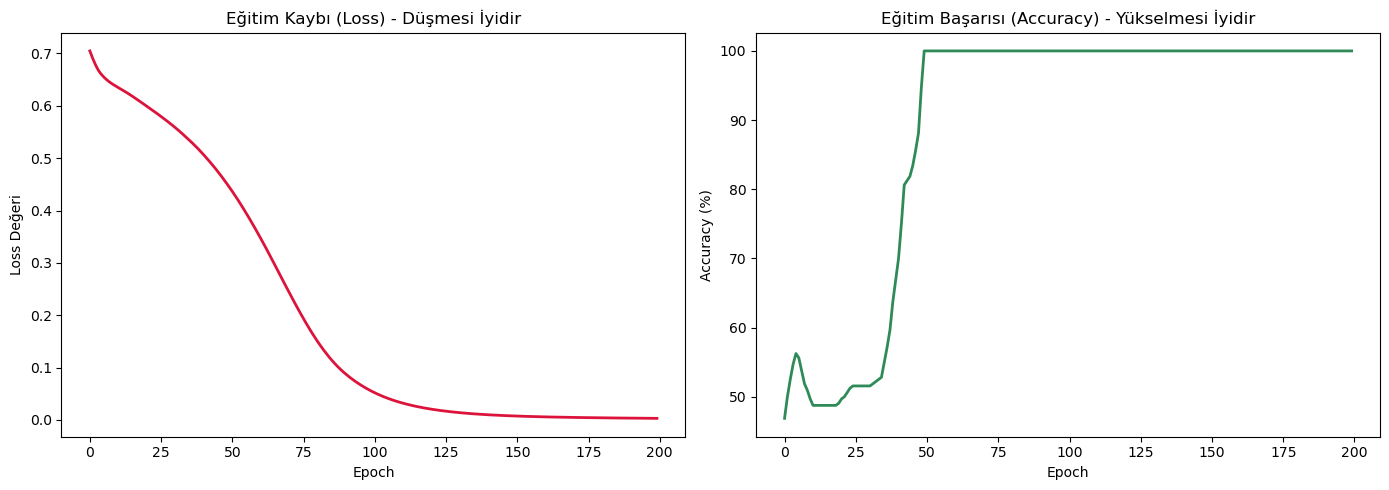

In [19]:
def plot_training_history(epochs_list, loss_list, acc_list):
    """
    Eğitim sürecindeki Kayıp (Loss) ve Başarı (Accuracy) değişimini yan yana çizer.
    """
    # 1 satır, 2 sütunluk (yan yana) bir grafik panosu aç
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sol taraf (Loss grafiği) - Kırmızı renk
    sns.lineplot(x=epochs_list, y=loss_list, ax=axes[0], color='crimson', linewidth=2)
    axes[0].set_title("Eğitim Kaybı (Loss) - Düşmesi İyidir")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss Değeri")
    
    # Sağ taraf (Accuracy grafiği) - Yeşil renk
    sns.lineplot(x=epochs_list, y=acc_list, ax=axes[1], color='seagreen', linewidth=2)
    axes[1].set_title("Eğitim Başarısı (Accuracy) - Yükselmesi İyidir")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    
    plt.tight_layout()
    plt.show()
plot_training_history(epoch_count, train_loss_count, train_acc_count)